__Probabilistic Programming. Wąsowski. Pardo. IT University of Copenhagen__

Some figures from 
* McElreath. _Statistical Rethinking. A Bayesian course with examples in R and STAN._ 2nd Ed.
* Kruschke. _Doing Bayesian Data Analysis. A tutorial with R, JAGS, and STAN._ 2nd Ed.

Adaptations of R examples to PymC3 courtesy of https://github.com/pymc-devs/resources/tree/master/Rethinking_2


In [1]:
import os
import warnings
import math

import arviz as az
from causalgraphicalmodels import CausalGraphicalModel
import matplotlib.animation
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import scipy.stats as stats
import pandas as pd
import rethinking as rt
import xarray as xr
import graphviz
from IPython.display import display, Markdown
from scipy.special import logsumexp

from numpy.typing import NDArray
from typing import Callable

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
hdi_fill_args = { 'color': 'gray', 'alpha': 0.2 }

import warnings

/Users/matusstanko/6-semester/2026-prpro-spring/.venv/lib/python3.14/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Week 6.  Non-linear Interactions in Regression 
(McElreath Ch. 8)

# Agenda

1. Interactions with categorical regressors
2. Interactions with continuous regressors

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Survival Bias as Conditioning

<img src="fig/fig-00.png" width="60%"/>

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

The evidence from bombers and manatees is misleading, because it is **conditioned on survival**.

<img src="fig/fig-01.png" width="57%"/>

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

This could be the causal graph for this problem:
$$(U) \rightarrow D \rightarrow S$$

* Every model so far assumed that each predictor has an __independent association with the mean of the outcome__.
* This could be sufficient for examples like above (the marriage--happiness model was similar).

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Conditioning Everywhere (Section 8.1)

* **Every statistical model** is conditioned on something
* A linear regression model (as seen so far) is conditioned on the fact that each regressor has an **independent (or univariate) impact** on the predicted variable.
* __Interaction__: the influence of one predictor depends upon another predictor
* Interaction is a further __conditioning__, allowing the fit parameters to depend on more than one aspect of the data directly.

* Interactions are "__epicycles__" in a "geocentric model" 
    - to be used __carefully__, when we actually understand that the __underlying reality__ should display such dependencies.
* They are much __harder to interpret__ than a purely linear regression model.
* They are not clearly visible in causal graphs

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Example: Terrain Ruggedness vs Economy

<img src="fig/fig-02.png" width="66%"/>

* We regress of __terrain ruggedness__ vs __economic performance__ (log GDP per capita, year 2000)
* A casual graph like the following might describe the situation:
    - $R$ is the rugedness
    - $G$ is the GDP
    - $C$ is continent
    - $U$ are unobserved confounds
    
<img src="fig/fig-03.png" width="27%" />

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Separate regression for Africa and Outside

<img src="fig/fig-04.png" width="80%"/>

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

* __Ruggedness__ is measured using Terrain Ruggedness index that quantifies the topographic heterogeneity of landscape
* Ruggedness is associated with reduced domestic product (harder, more expensive transport)
* Except if we are in Africa, where it (possibly) could have made exploitation harder
* Gross Domestic Product (GDP) is measured on log scale (__log GDP__), since wealth seems to be related to anything that increases wealth (__wealth generates wealths__)

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Problems with Our DAG

<img src="fig/fig-03.png" width="23%" />

* The DAG __captures the independent influence__ of $R$ and $C$ on $G$, but does not capture the fact that this influence could be interacting (so the influence of ruggedness can change depending on the continent).
* Maybe there is a __functional dependency__ $G = f (R, C)$ that we'd like to investigate statistically (compare different candidates)
  - perhaps $f$ is different than $\beta_1 R + \beta_2 C$
  - perhaps if is not even additive

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# What's wrong with the separate regressions?

1. __Not all parameters depend on the continent__ (like $\sigma$ of GDP). 
    - When we split the data, we have less information in each of the splits to estimate these parameters.  Inference is stronger when we use the entire data set.


2. __Separate models cannot investigate how the continent influences the relationship between ruggedness and GDP__.
    - Is the split certain? If you want to assess uncertainty of this influence, the continent needs to be in the model, which means a single model and a single regression.
    - When you split the model is like making a super strong prior, stating that this indeed are completely different situations. But what if you do not have that super strong prior?


3. __To use information criteria to compare models, all the models need to use the same data.__


4. __Different parts of the models learn from each other (AKA _shrinkage_) if they are all together.__  
    - When you split, you prevent learning/inference across categories.
    - If some categories are very small (less data), there is a higher risk of overfitting, but the other categories regularize the result.

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# A Model for GDP with Interactions

* Assume $\mathrm{CID}[i]$ denotes the continent (zero or 1, Africa, or outside) of the $i$th entry in the dataset

$$\log (y_i) \sim \mathrm{Normal}(\mu_i, \sigma)$$

$$\large\mu_i = \alpha_{\mathrm{CID}[i]} + \beta_{\mathrm{CID}[i]}(r_i - \overline{r})$$

$$\alpha_{\mathrm{CID}[i]} \sim \mathrm{Normal}(1, 0.1)$$

$$\beta_{\mathrm{CID}[i]} \sim \mathrm{Normal}(0, 0.3)$$

$$\sigma \sim \mathrm{Exponential(1)}$$

* The data has been __normalized__ so that 
  - Raggedness ranges from 0 to 1 (as zero is meaningful in this problem)
  - The average GDP is 1 (so we divide by the mean of the sample), so a deviation from some norm
  - This makes it easier to assign priors, and to understand results
  - Note that in the model will still shift the ruggedness by the mean, to improve inference
  
* Let's make this data normalization and build the model in Python

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Reading the GDP Data

In [2]:
d = pd.read_csv("rugged.csv", delimiter=";").to_xarray()
d

<xarray.Dataset> Size: 97kB
Dimensions:                 (index: 234)
Coordinates:
  * index                   (index) int64 2kB 0 1 2 3 4 ... 229 230 231 232 233
Data variables: (12/51)
    isocode                 (index) object 2kB 'ABW' 'AFG' 'AGO' ... 'ZMB' 'ZWE'
    isonum                  (index) int64 2kB 533 4 24 660 8 ... 887 710 894 716
    country                 (index) object 2kB 'Aruba' ... 'Zimbabwe'
    rugged                  (index) float64 2kB 0.462 2.518 ... 0.533 1.194
    rugged_popw             (index) float64 2kB 0.38 1.469 0.714 ... 0.506 1.106
    rugged_slope            (index) float64 2kB 1.226 7.414 ... 1.422 3.232
    ...                      ...
    dist_slavemkt_atlantic  (index) float64 2kB nan nan 5.669 ... 9.027 9.027
    dist_slavemkt_indian    (index) float64 2kB nan nan 6.981 ... 2.389 2.389
    dist_slavemkt_saharan   (index) float64 2kB nan nan 4.926 ... 4.849 5.454
    dist_slavemkt_redsea    (index) float64 2kB nan nan 3.872 ... 3.253 3.696
    pop_1400                (index) float64 2kB 614.0 1.871e+06 ... 1.741e+05
    european_descent        (index) float64 2kB nan 0.0 2.0 nan ... 18.0 1.0 1.0

In [3]:
# Make log version of the outcome
d["log_gdp"] = np.log(d.rgdppc_2000)

In [4]:
# Extract countries with GDP data (drop incomplete rows)
dd = d.dropna(dim='index', subset=["log_gdp"])

In [5]:
# Rescale variables as described above
log_gdp_mean = dd.log_gdp.mean()
rugged_max = dd.rugged.max()

In [6]:
dd["log_gdp_std"] = dd.log_gdp / log_gdp_mean
dd["rugged_std"] = dd.rugged / rugged_max
# we will use this mean below to center the rugged_std dimension
# apparently if you we do not use item() then we get a zero dimensioned DataArray 
# which causes issues later. The last call converts this to a scalar. Thanks ChatGPT
rugged_std_mean = dd.rugged_std.mean().item()

In [7]:
dd

<xarray.Dataset> Size: 75kB
Dimensions:                 (index: 170)
Coordinates:
  * index                   (index) int64 1kB 2 4 7 8 9 ... 229 230 231 232 233
Data variables: (12/54)
    isocode                 (index) object 1kB 'AGO' 'ALB' 'ARE' ... 'ZMB' 'ZWE'
    isonum                  (index) int64 1kB 24 8 784 32 51 ... 887 710 894 716
    country                 (index) object 1kB 'Angola' 'Albania' ... 'Zimbabwe'
    rugged                  (index) float64 1kB 0.858 3.427 ... 0.533 1.194
    rugged_popw             (index) float64 1kB 0.714 1.597 ... 0.506 1.106
    rugged_slope            (index) float64 1kB 2.274 10.45 ... 1.422 3.232
    ...                      ...
    dist_slavemkt_redsea    (index) float64 1kB 3.872 nan nan ... 3.253 3.696
    pop_1400                (index) float64 1kB 1.223e+06 2e+05 ... 1.741e+05
    european_descent        (index) float64 1kB 2.0 100.0 0.0 ... 18.0 1.0 1.0
    log_gdp                 (index) float64 1kB 7.493 8.217 ... 6.652 7.824
    log_gdp_std             (index) float64 1kB 0.8797 0.9648 ... 0.781 0.9186
    rugged_std              (index) float64 1kB 0.1383 0.5526 ... 0.08594 0.1925

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# The Regression Model with Interactions

In [8]:
with pm.Model() as m_8_3:
    
    # 'categories' will be just equal to two (2) in this case (Africa vs Non-Africa), 
    # but  the code shows how to do this in general, if there are
    # more discrete values
    
    categories = np.unique(dd.cont_africa.values).size

    # The shape allows as to make `a` and `b` into vectors
    a = pm.Normal("a", 1, 0.1, shape = categories)
    b = pm.Normal("b", 0, 0.3, shape = categories)

    R = pm.Data("R", dd.rugged_std.values - rugged_std_mean)
    CID = pm.Data("CID", dd.cont_africa.values)
    LG = pm.Data("LG", dd.log_gdp_std.values)

    mu = pm.Deterministic("mu", a[CID] + b[CID] * R)
  
    sigma = pm.Exponential("sigma", lam = 1)

    log_gdp_std = pm.Normal("log_gdp_std", mu = mu, sigma = sigma, observed = LG)

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

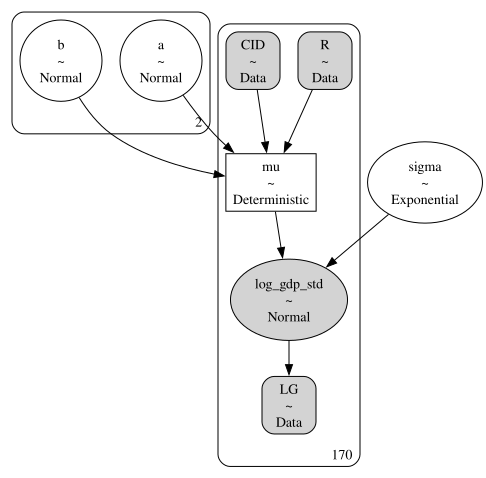

In [9]:
pm.model_graph.model_to_graphviz(m_8_3)

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

In [10]:
with m_8_3:
    m_8_3_trace = pm.sample(random_seed = rng)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, b, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


# Analyze the Posterior for Ruggedness

In [11]:
az.summary(m_8_3_trace, kind="stats", round_to=2)

,mean,sd,hdi_3%,hdi_97%
a[0],1.05,0.01,1.03,1.07
a[1],0.89,0.02,0.86,0.92
b[0],-0.14,0.06,-0.25,-0.04
b[1],0.13,0.08,-0.01,0.27
sigma,0.11,0.01,0.10,0.12
...,...,...,...,...
mu[165],1.04,0.01,1.02,1.06
mu[166],1.03,0.01,1.00,1.05
mu[167],0.90,0.02,0.86,0.93
mu[168],0.87,0.02,0.84,0.90


* Clearly the African (1) __intercept is lower__ than elsewhere (0)
    - Reflects overall lower GDPs in Africa
    - This is what we did before for categorical regression (intercepts depend on categories)
* `b[1]` is positive, `b[0]` is negative
    - Clearly there is a __dependence of slope on the category__
    - Since category (continent) is a variable in the data, this is an _interaction_ between variables
    - This is new, the previous linear models were unable to capture this.

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Comparing with Simpler Models

* The book compares this model with models of 
    - joint simple __linear regression__ (m_8_1t) ignoring the continent
    - the model where __only the intercept depends on the continent__ (m_8_2), like we did in previous chapters


* Deviance is calculated using leave-one-out comparison (__loo__ column) below


* The differences between the best model and others are in __d_loo__


* Recall that deviance differences estimate which model has higher chance of a good out-of-sample prediction (last week)

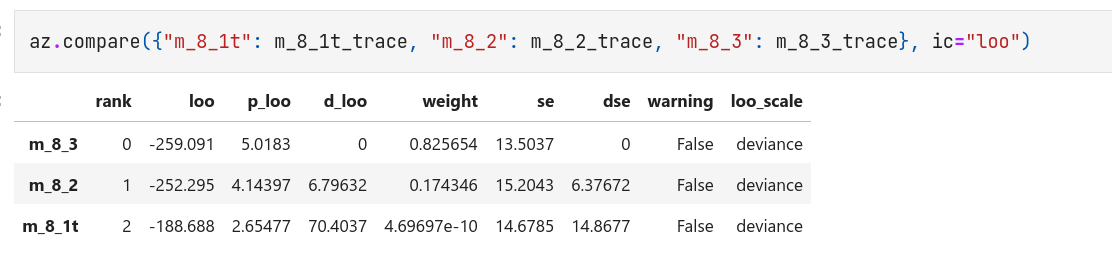

* Clearly the model with interactions (m_8_3) has __lowest deviance__ (d_loo, estimated using leave-one-out cross validation here, usin PSIS in the book)


* This indicates/ predicts that the model with interaction has __strongest predictive power__ (out of sample)

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Why Does the Model without Interaction Fail?

* The crucial part of the model (m_8_2), different from the interaction model above (compare with the interacting model above):

$$\large\mu_i = \alpha_{\mathrm{CID}[i]} + \beta(r_i - \overline{r})$$

* Basically, it allows for different intercept, but the slope is from the same distribution across continents
* This results in the following posterior (conditioned on category):

<img src="fig/fig-05.png" width="90%"/>

* A model in which there is no interaction, just different intercepts, is unable to recover different slopes
    - It basically just shifts the line.
    - Reflects __the differences in GDP levels__
    - Does not reflect the differences in the __nature of dependencies__

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Plotting the Model with Interactions (Fig. 8.5)

We first sample the posterior predictive distributions

In [12]:
rugged_plot = xr.DataArray(np.linspace(-0.05, 1.05, 60))

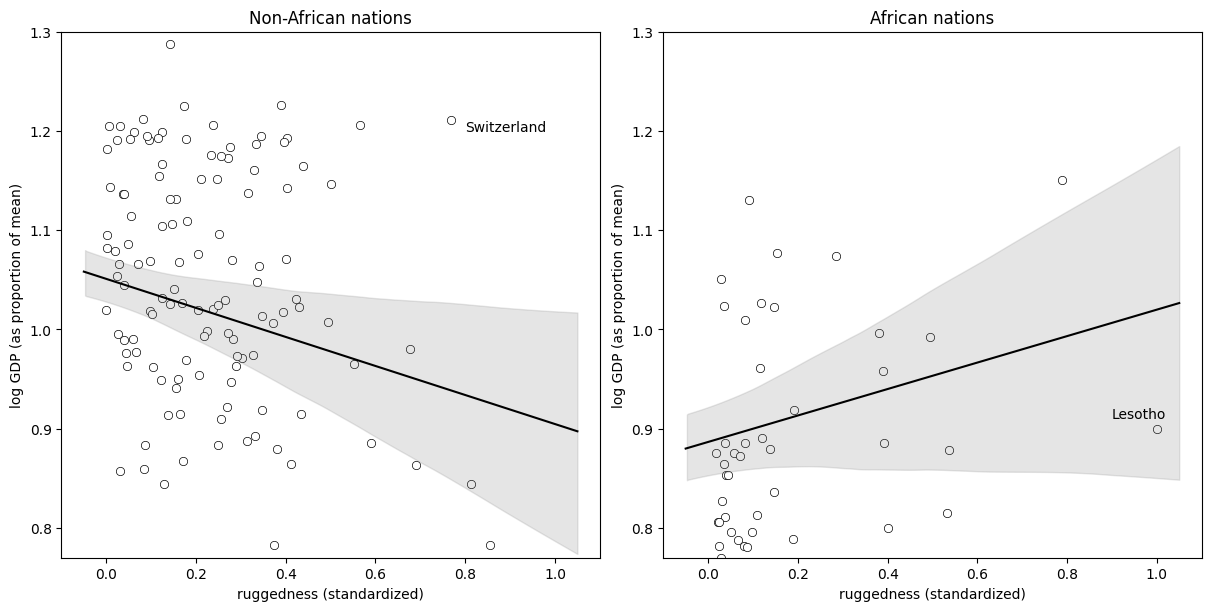

In [13]:
_, ax = plt.subplots(1,2, figsize=(12, 6), constrained_layout = True )

# Calculating predictions for new points manually because 
# this is a pain with categorical variables in PyMC
# The problem seems to be that the predictions group contains 
# variants of the regression parameters for each group, but 
# not the values of the predicted variables. These seem to 
# be available only for the second group (if one can trust the name).
#
# Another issue is that we would like to have a prediction for 
# rugged_plot points for both groups, but 
# it seems that this is not supported. One would have to assign 
# different points to each groups and provide a new CID vector, or 
# run the prediction sample twice. Better work with the posterior directly.

post = m_8_3_trace.posterior.sel(chain = 0).drop_vars('chain')

labels = [ "Non-African nations", "African nations" ]

for i in range(post.a_dim_0.size):
    ax[i].scatter(
        dd.where(dd.cont_africa == i, drop = True).rugged_std,
        dd.where(dd.cont_africa == i, drop = True).log_gdp_std,
        label = labels[i],
        facecolor = "w",
        lw = 0.5,
        edgecolor = "k",
    )

    mu = post.a[:,i] + rugged_plot * post.b[:,i]

    # Next year we will need to change the shape of mu.values
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)
        az.plot_hdi(rugged_plot, mu.values, hdi_prob = 0.97, ax = ax[i], fill_kwargs = hdi_fill_args)
        
    ax[i].plot(rugged_plot, mu.values.mean(axis = 0), color = "k")

    ax[i].set_xlim(-0.1, 1.1)
    ax[i].set_ylim(0.77, 1.3)
    ax[i].set_title(labels[i])
    ax[i].set_xlabel("ruggedness (standardized)")
    ax[i].set_ylabel("log GDP (as proportion of mean)")

ax[0].text(0.8, 1.2, "Switzerland")
ax[1].text(0.9, 0.91, "Lesotho")

plt.show()

* Shading shows 97% HDI for the lines
* The slopes are __more pronounced__ than with separate regression
* Like in the other our plots, we seem to be getting (a bit) wider HDIs (a bit more variance) than the book, most likely because of different approximations of the HDI endpoints by MCMC vs Quadratic Approximation

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Symmetry of Interactions (Section 8.2)

* Interactions are __symmetric__ (like corellations)


* In the previous example we have intuited that __continent changes ruggedness' influence on GDP__


* In fact this could be interpreted dually: that the __ruggedness changes the continents influence on GDP__


* Interactions are not casual, but descriptive/predictive/geocentric

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Continuous Interactions (Section 8.3)

* The above example shows how a discrete (continent) and a continues (ruggedness index) interact influencing GDP


* With a discrete/categorical predictor, we basically have a __vector of slopes__


* But what to do if __two continuous predictors interact__?
    - We can represent other functional dependencies of prediction on the interaction
    - A polynomial (non-linear) interaction is typically considered
    - You could imagine other functional dependencies as well (again arbitrary "epicycles") 
    - This is what neural networks do...


* The maths is almost the same as for categorical variables, but __interpretation becomes more difficult__.

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Example: Size of Tulip Blooms

<img src="fig/fig-06.png" width ="20%" />

In [14]:
d = pd.read_csv("tulips.csv", delimiter=";").to_xarray()
d

<xarray.Dataset> Size: 1kB
Dimensions:  (index: 27)
Coordinates:
  * index    (index) int64 216B 0 1 2 3 4 5 6 7 8 ... 18 19 20 21 22 23 24 25 26
Data variables:
    bed      (index) object 216B 'a' 'a' 'a' 'a' 'a' 'a' ... 'c' 'c' 'c' 'c' 'c'
    water    (index) int64 216B 1 1 1 2 2 2 3 3 3 1 1 ... 3 3 1 1 1 2 2 2 3 3 3
    shade    (index) int64 216B 1 2 3 1 2 3 1 2 3 1 2 ... 2 3 1 2 3 1 2 3 1 2 3
    blooms   (index) float64 216B 0.0 0.0 111.0 183.5 ... 304.5 249.3 134.6

* Some standardization

In [15]:
d["blooms_std"] = d.blooms / d.blooms.max()
d["water_cent"] = d.water - d.water.mean()
d["shade_cent"] = d.shade - d.shade.mean()

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# A Model for Bloom Regression

* __Predict the bloom size,__ given the access to __water__ and the amount of __shade__

* Some possible influences: 
    - If you have lots of water but no sun, the growth is not possible
    - If you have lots of sun but no water, the growth is not possible
    - Some water and some sun, the bloom should grow well

<br/>

* It seems that these to regressors do not influence the __target independently,__ but in an interacting fashion

$$B_i \sim \mathrm{Normal}(\mu_i,\sigma)$$

$$\large \mu_i = \alpha + \beta_WW_i + \beta_SS_i + \beta_{WS}S_iW_i$$

$$\cdots$$

* Note that $\beta_{WS}$ has __no easily interpretable meaning__, unlike $\beta_W$ and $\beta_S$ which shall  describe a change of the target variable per unit change of each regressor (but the interaction term arguably obscures it).
* McElreath calls this an "epicycle" term, like the epicycles in the geocentric model - not natural, not explainable, but possibly improving predictions.

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# The Model in Python

First a model without interactions

In [16]:
with pm.Model() as m_8_4:
    a = pm.Normal("a", 0.5, 0.25)
    bw = pm.Normal("bw", 0, 0.25)
    bs = pm.Normal("bs", 0, 0.25)
    sigma = pm.Exponential("sigma", 1)
    
    mu = pm.Deterministic("mu", a + bw * d.water_cent.values + bs * d.shade_cent.values)
    blooms_std = pm.Normal("blooms_std", mu, sigma, observed = d.blooms_std.values)

    m_8_4_trace = pm.sample(3000, random_seed = rng)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, bw, bs, sigma]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 1 seconds.


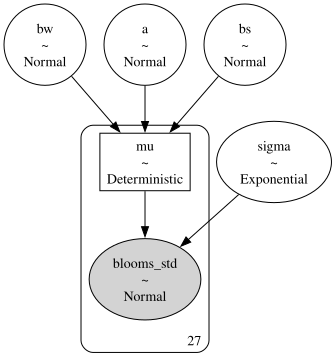

In [17]:
pm.model_graph.model_to_graphviz(m_8_4)

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

Second, a model with an interaction term

In [18]:
with pm.Model() as m_8_5:
    a = pm.Normal("a", 0.5, 0.25)
    bw = pm.Normal("bw", 0, 0.25)
    bs = pm.Normal("bs", 0, 0.25)
    bws = pm.Normal("bws", 0, 0.25)

    mu = pm.Deterministic("mu", 
         a +  bw * d.water_cent.values \
           +  bs * d.shade_cent.values \
           + bws * d.water_cent.values * d.shade_cent.values)
    sigma = pm.Exponential("sigma", 1)

    blooms_std = pm.Normal("blooms_std", mu, sigma, observed = d.blooms_std.values)

    m_8_5_trace = pm.sample(random_seed = rng)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, bw, bs, bws, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


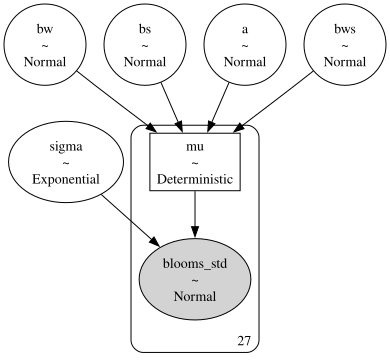

In [19]:
pm.model_graph.model_to_graphviz(m_8_5)

<br/><br/><br/><br/><br/><br/><br/><br/><br/><br/>

# Plotting Models without and with Interactions (Fig 8.7)

* A 3D plot could be an option, although often things are hard to see
* Arviz supports 3D plots, and they can give you some idea of the shape (feel free to try in your project work and experiments)
* McElreath promotes a tryptych: three bivariate plots, at different levels of one of the regressors (extreme low, medium, extreme high)

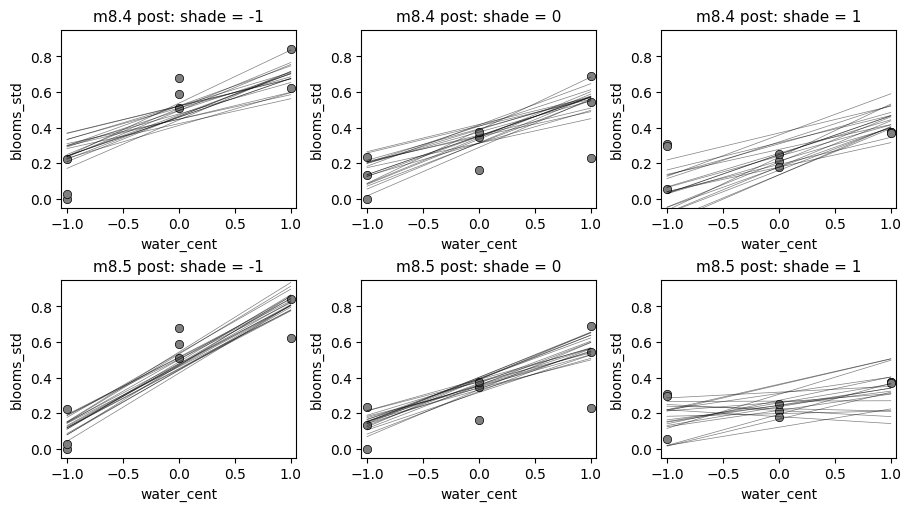

In [20]:
_, axs = plt.subplots(2, 3, figsize = [9, 5], constrained_layout = True)

n_lines = 20
pred_x = xr.DataArray([-1, 1])

for i, shade in enumerate([-1, 0, 1]):

    for ax in axs[:, i]:
        rows = d.where(d.shade_cent == shade, drop = True)
        ax.scatter(rows.water_cent, rows.blooms_std, facecolor = "gray", lw = 0.5, edgecolor = "k",)
        ax.set_xlabel("water_cent")
        ax.set_ylabel("blooms_std")
        ax.set_xlim(-1.05, +1.05)
        ax.set_ylim(-0.05, 0.95)
    
    # top row: m_8_4
    ax = axs[0, i]
    ax.set_title(f"m8.4 post: shade = {shade:.0f}", fontsize = 11)
    pred_y = (
          m_8_4_trace.posterior.a[0][:n_lines]
        + pred_x * m_8_4_trace.posterior.bw[0][:n_lines]
        + shade * m_8_4_trace.posterior.bs[0][:n_lines]
    )
    ax.plot(pred_x, pred_y.T, lw=0.5, color="k", alpha = 0.5)

    # bottom row, m_8_5
    ax = axs[1, i]
    ax.set_title(f"m8.5 post: shade = {shade:.0f}", fontsize=11)
    pred_y = (
        m_8_5_trace.posterior["a"][0][:n_lines]
        + m_8_5_trace.posterior["bw"][0][:n_lines] * pred_x
        + m_8_5_trace.posterior["bs"][0][:n_lines] * shade
        + m_8_5_trace.posterior["bws"][0][:n_lines] * pred_x * shade
    )
    ax.plot(pred_x, pred_y.T, lw = 0.5, color = "k", alpha = 0.5)

plt.show()

* Top without interaction, bottom with interaction
* Each shows 20 lines drawn from the posterior
* Note how 
    - the influence of water on growth disappears in the bottom right
    - it is very strong in the bottom left
    - the top graphs just shift on the vertical axis (shift in intercept), not slope (there is some adjustment thanks to multiple regression, selection from the multivariate, but it is weak)